Exception in Tkinter callback
Traceback (most recent call last):
  File "C:\Users\user\anaconda3\lib\tkinter\__init__.py", line 1921, in __call__
    return self.func(*args)
  File "C:\Users\user\AppData\Local\Temp\ipykernel_6160\3102884704.py", line 194, in <lambda>
    command=lambda: plot_trend(ingredient_search, "검색수", "search"),
  File "C:\Users\user\AppData\Local\Temp\ipykernel_6160\3102884704.py", line 175, in plot_trend
    ax.plot(x_data, y_data,
  File "C:\Users\user\anaconda3\lib\site-packages\matplotlib\axes\_axes.py", line 1688, in plot
    lines = [*self._get_lines(*args, data=data, **kwargs)]
  File "C:\Users\user\anaconda3\lib\site-packages\matplotlib\axes\_base.py", line 311, in __call__
    yield from self._plot_args(
  File "C:\Users\user\anaconda3\lib\site-packages\matplotlib\axes\_base.py", line 504, in _plot_args
    raise ValueError(f"x and y must have same first dimension, but "
ValueError: x and y must have same first dimension, but have shapes (25,) and (50,)


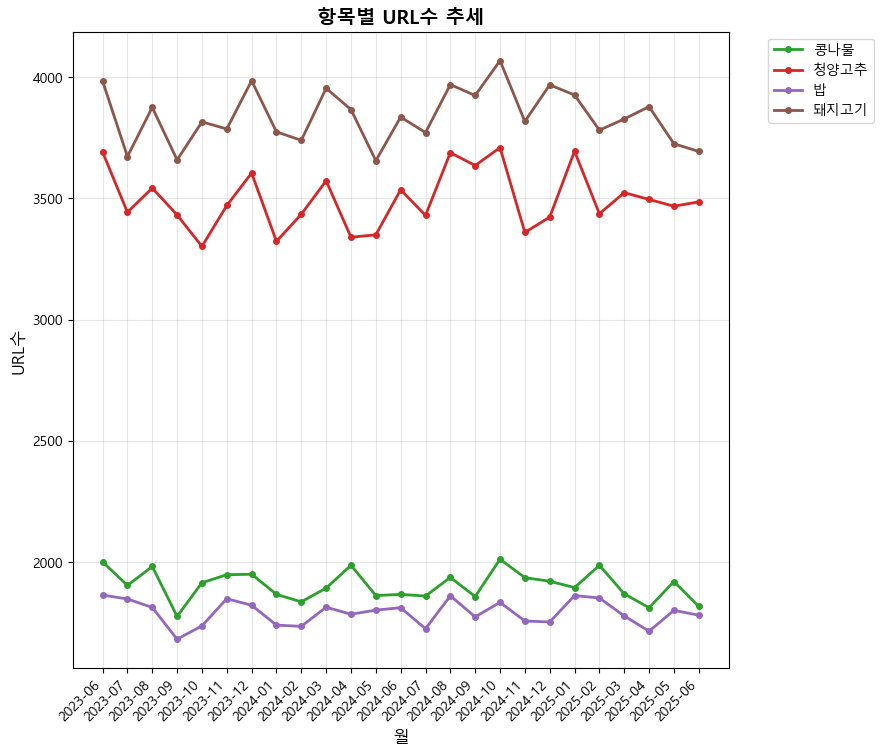

In [2]:
import pandas as pd
import numpy as np
import tkinter as tk
from tkinter import messagebox, ttk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# --- 한글 폰트 설정 ---
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# --- 경로 및 파일 설정 ---
recipe_file = "병합_레시피_포함매핑적용_380개메뉴포함.xlsx"
merged_file = "상세메뉴_통합결과_URL포함.xlsx"
output_file = "항목별_월별추세_계산결과.xlsx"

# --- 데이터 처리 ---
sheet_names = pd.ExcelFile(recipe_file).sheet_names
sheet1 = pd.read_excel(recipe_file, sheet_name=sheet_names[0], index_col=0)
sheet2 = pd.read_excel(recipe_file, sheet_name=sheet_names[1], index_col=0)
binary_matrix = pd.concat([sheet1, sheet2])

# 헤더나 잘못된 항목 제거
binary_matrix = binary_matrix[binary_matrix.index != '항목']
binary_matrix = binary_matrix[~binary_matrix.index.isna()]
binary_matrix = binary_matrix[binary_matrix.index != '']

binary_matrix = binary_matrix.replace('-', np.nan)
binary_matrix = binary_matrix.notna().astype(int)

search_df = pd.read_excel(merged_file, sheet_name=0)
search_df.set_index("상세메뉴", inplace=True)
search_df = search_df.loc[~search_df.index.duplicated(keep='first')]

search_cols = search_df.columns[-75:-50]
adjust_cols = search_df.columns[-50:-25]
url_cols = search_df.columns[-25:]

search_trend = search_df[search_cols]
adjust_trend = search_df[adjust_cols]
url_trend = search_df[url_cols]

recipe_menus = set(binary_matrix.columns)
trend_menus = set(search_trend.index)
common_menus = sorted(recipe_menus & trend_menus)

binary_matrix_filtered = binary_matrix[common_menus]
search_trend = search_trend.loc[common_menus]
adjust_trend = adjust_trend.loc[common_menus]
url_trend = url_trend.loc[common_menus]

ingredient_search = binary_matrix_filtered @ search_trend.fillna(0)
ingredient_adjust = binary_matrix_filtered @ adjust_trend.fillna(0)
ingredient_url = binary_matrix_filtered @ url_trend.fillna(0)

with pd.ExcelWriter(output_file) as writer:
    ingredient_search.to_excel(writer, sheet_name="검색수_항목별_추세")
    ingredient_adjust.to_excel(writer, sheet_name="보정검색수_항목별_추세")
    ingredient_url.to_excel(writer, sheet_name="URL수_항목별_추세")

# --- Tkinter 시각화 UI ---
def create_interface():
    root = tk.Tk()
    root.title("항목별 3종 추세 시각화")
    root.geometry("1200x800")

    # 왼쪽 프레임 (컨트롤)
    left_frame = tk.Frame(root)
    left_frame.pack(side='left', fill='y', padx=10, pady=10)

    # 제목
    tk.Label(left_frame, text="항목별 추세 분석", font=('Arial', 14, 'bold')).pack(pady=(0, 10))

    # 항목 선택 리스트박스
    tk.Label(left_frame, text="항목 선택 (최대 5개)", font=('Arial', 12)).pack()
    
    # 선택 개수 표시
    selection_count_label = tk.Label(left_frame, text="선택된 항목: 0/5", fg='blue')
    selection_count_label.pack(pady=5)

    # 리스트박스와 스크롤바
    listbox_frame = tk.Frame(left_frame)
    listbox_frame.pack(fill='both', expand=True, pady=5)

    scrollbar = tk.Scrollbar(listbox_frame)
    scrollbar.pack(side='right', fill='y')

    lb = tk.Listbox(listbox_frame, selectmode=tk.MULTIPLE, width=35, height=20, 
                    yscrollcommand=scrollbar.set)
    lb.pack(side='left', fill='both', expand=True)
    scrollbar.config(command=lb.yview)

    # 항목 추가
    for item in ingredient_search.index:
        lb.insert(tk.END, item)

    # 선택 개수 제한 함수
    def on_selection_change(event):
        selected_count = len(lb.curselection())
        if selected_count > 5:
            # 선택이 5개를 초과하면 마지막 선택을 해제
            selections = list(lb.curselection())
            lb.selection_clear(selections[-1])
            selected_count = 5
            messagebox.showwarning("선택 제한", "최대 5개까지만 선택할 수 있습니다.")
        
        selection_count_label.config(text=f"선택된 항목: {selected_count}/5")

    # 선택 변경 이벤트 바인딩
    lb.bind('<<ListboxSelect>>', on_selection_change)

    # 구분선
    ttk.Separator(left_frame, orient='horizontal').pack(fill='x', pady=10)

    # 버튼 프레임
    btn_frame = tk.Frame(left_frame)
    btn_frame.pack(pady=10)

    # 오른쪽 프레임 (그래프)
    graph_frame = tk.Frame(root)
    graph_frame.pack(side='right', fill='both', expand=True, padx=10, pady=10)

    # 그래프
    fig, ax = plt.subplots(figsize=(12, 8))
    canvas = FigureCanvasTkAgg(fig, master=graph_frame)
    canvas.get_tk_widget().pack(fill='both', expand=True)

    # 초기 메시지
    ax.text(0.5, 0.5, '항목을 선택하고 원하는 추세 버튼을 클릭하세요.\n\n- 검색수 추세 보기\n- 보정검색수 추세 보기\n- URL수 추세 보기', 
            horizontalalignment='center', verticalalignment='center', transform=ax.transAxes,
            fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    canvas.draw()

    # 그래프 그리기 공통 함수
    def plot_trend(data_source, data_name, color_scheme='default'):
        selected = lb.curselection()
        if len(selected) == 0:
            messagebox.showwarning("선택 오류", "항목을 1개 이상 선택하세요.")
            return
        if len(selected) > 5:
            messagebox.showwarning("선택 오류", "최대 5개까지만 선택할 수 있습니다.")
            return
        
        selected_items = [lb.get(i) for i in selected]
        
        ax.clear()
        
        # 색상 팔레트 설정
        if color_scheme == 'search':
            colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # 파란 계열
        elif color_scheme == 'adjust':
            colors = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']  # 주황 계열
        elif color_scheme == 'url':
            colors = ['#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']  # 초록 계열
        else:
            colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # 기본
        
        # 데이터 확인 및 처리
        for i, item in enumerate(selected_items):
            if item not in data_source.index:
                print(f"Warning: {item}이 데이터에 없습니다.")
                continue
                
            color = colors[i % len(colors)]
            # 데이터 추출 시 1차원으로 변환
            y_data = data_source.loc[item].values
            if y_data.ndim > 1:
                y_data = y_data.flatten()
            
            x_data = list(range(len(data_source.columns)))  # 인덱스 기반으로 x축 설정
            
            ax.plot(x_data, y_data, 
                   label=f"{item}", marker='o', linewidth=2, color=color, markersize=4)
        
        ax.set_title(f"항목별 {data_name} 추세", fontsize=14, fontweight='bold')
        ax.set_xlabel("월", fontsize=12)
        ax.set_ylabel(data_name, fontsize=12)
        
        # x축 레이블을 실제 열 이름으로 설정
        ax.set_xticks(range(len(data_source.columns)))
        ax.set_xticklabels(data_source.columns, rotation=45, ha='right')
        
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        
        fig.tight_layout()
        canvas.draw()

    # 각 데이터 타입별 버튼
    tk.Button(btn_frame, text="검색수 추세 보기", 
              command=lambda: plot_trend(ingredient_search, "검색수", "search"),
              bg='lightblue', font=('Arial', 10, 'bold'), width=15).pack(pady=2, fill='x')
    
    tk.Button(btn_frame, text="보정검색수 추세 보기", 
              command=lambda: plot_trend(ingredient_adjust, "보정검색수", "adjust"),
              bg='lightgreen', font=('Arial', 10, 'bold'), width=15).pack(pady=2, fill='x')
    
    tk.Button(btn_frame, text="URL수 추세 보기", 
              command=lambda: plot_trend(ingredient_url, "URL수", "url"),
              bg='lightcoral', font=('Arial', 10, 'bold'), width=15).pack(pady=2, fill='x')

    # 전체 선택/해제 버튼
    def select_all():
        lb.selection_set(0, min(4, lb.size()-1))  # 최대 5개까지만 선택
        on_selection_change(None)

    def clear_selection():
        lb.selection_clear(0, tk.END)
        on_selection_change(None)

    # 추가 버튼들
    ttk.Separator(left_frame, orient='horizontal').pack(fill='x', pady=5)
    
    util_frame = tk.Frame(left_frame)
    util_frame.pack(pady=5)
    
    tk.Button(util_frame, text="상위 5개 선택", command=select_all, 
              font=('Arial', 9), width=12).pack(side='left', padx=2)
    tk.Button(util_frame, text="선택 해제", command=clear_selection, 
              font=('Arial', 9), width=12).pack(side='right', padx=2)

    root.mainloop()

# 실행
if __name__ == "__main__":
    create_interface()